<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/04_particle_extraction_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [ ]:
do = False # @param{type:"boolean"}
if do:
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq
    %pip install starfile -qq
    %pip install https://github.com/soft-matter/trackpy/archive/master.zip -qq

In [ ]:
if do:
    !git clone https://github.com/phonchi/CryoParticleSegment.git

    !wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
    !wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
    !wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
    !wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

In [ ]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
if do:
    #%git clone https://github.com/netw0rkf10w/CRF.git
    %cd CryoParticleSegment/Modeling/CRF_main
    !python setup.py clean --all
    !rm -rf build/
    !python setup.py build_ext --inplace --force
    !python setup.py install

> #### ⚠ Notice
>
> You need to restart the kernel after the following step.

In [ ]:
if do:
    %pip install pycuda==2024.1
    %pip install "numpy<2.0"
    %pip install mrcfile -qq

## ⭐ Setup
You must run all codes under this category.

### ✅ Directory Settings

In [ ]:
# @title  { display-mode: "form" }

INPUT_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
IMAGE_DIR = INPUT_IMAGE_DIR
# @markdown ---

use_denoised_as_pariwise = False # @param {type : "boolean"}
dnzd_pw = use_denoised_as_pariwise
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
# @markdown ---

LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
DATASET_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_clustering/10017/unet_eb5_dice_CRF" # @param {type:"string"}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
rm: cannot remove '/content/sample_data': No such file or directory


In [ ]:
IMAGE_DIR = "/content/image_dir"

In [ ]:
%cd /content/

/content


### ✅ Packages Handling

In [ ]:
# @title  { display-mode: "form" }
# @markdown Useful packages.

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR

In [ ]:
# @title  { display-mode: "form" }
# @markdown User-defined packages.

from dataset import MicrographDataset, MicrographDatasetEvery
from dataset import reconstruct_patched, collate_fn
from model import create_model
from trainer import CryoEMEvaluator
from trainer import CryoEMTrainerWithScheduler, tqdm_plugin_for_Trainer

## ⭐ Main

### ✅ Setting

In [ ]:
# @markdown Parameters.

NUM_CLASSES = 2
EPOCHS = 50
BATCH = 8
CROP_SIZE = (512, 512)
LR = 1e-3

RLR_PATIENCE = 3
ES_PATIENCE = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

## ⭐ Convcrf wtih FCN finetuned on cryoem

### ✅ Model

## The model

In [ ]:
# @title  { display-mode: "form" }

architecture = "Unet++" # @param {type:"string"}
encoder = "timm-efficientnet-b5" # @param {type:"string"}
pretrained = True # @param {type:"boolean"}
solver = "fw" # @param {type:"string"}
use_unary_only = False # @param {type:"boolean"}


In [ ]:
import segmentation_models_pytorch as smp

if pretrained:
  weights = "imagenet"
else:
  weights = None

if architecture == "Unet++":
    backbone = smp.UnetPlusPlus(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` or `advprop` for pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )

elif architecture == "Deeplab":
    backbone = smp.DeepLabV3(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )
else:
    print("Architecture not supported")
    raise NotImplementedError

model = create_model(backbone, addout=True) #crf_args

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

In [ ]:
import CRF
import torch.nn as nn
from model import setup_crf, create_fwcrf_model

# Example usage
solver = 'fw'  # Assuming the solver type is defined

crf = setup_crf(solver, NUM_CLASSES)
model_post = create_fwcrf_model(model.backbone, crf, use_unary_only=True)

CRF solver: fw
x0_weight: 0.0
FrankWolfeParams: 
	 scheme:	 fixed 
	 stepsize:	 1.0 (for the 'fixed' scheme) 
	 regularizer:	 l2
	 lambda_:	 1.0
	 lambda_learnable:	 False
	 x0_weight:	 0.5
	 x0_weight_learnable:	 False
Non-trainable lambda for Frank-Wolfe: 1.0
Non-trainable x0_weight for Frank-Wolfe: 0.5
Potts: remove random weights.
Add 1.0 to spatial_weight diagonal
Add 1.0 to bilateral_weight diagonal
Add -1.0 to compatibility diagonal


## ⭐ Evaluate

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
from dataset import reconstruct_patched

def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy

In [ ]:
from torch.utils.data import ConcatDataset

train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
if dnzd_pw == False:
    train_dataset = MicrographDatasetEvery(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE)
else:
    dnzd_train_dir = os.path.join(DENOISED_IMAGE_DIR, 'train')
    train_dataset = MicrographDatasetEvery(image_dir=train_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=CROP_SIZE)
train_loader = DataLoader(train_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)


val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
if dnzd_pw == False:
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE)
else:
    dnzd_val_dir = os.path.join(DENOISED_IMAGE_DIR, 'val')
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=CROP_SIZE)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)


test_dir = os.path.join(IMAGE_DIR, 'test')
test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)

test_dir = os.path.join(IMAGE_DIR, 'test')
test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
if dnzd_pw == False:
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=None, filenames=test_filenames, crop_size=CROP_SIZE)
else:
    dnzd_test_dir = os.path.join(DENOISED_IMAGE_DIR, 'test')
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=None, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=CROP_SIZE)

test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)


full_filenames = np.concatenate((train_filenames, val_filenames, test_filenames))
full_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])
full_loader = DataLoader(full_dataset, batch_size=32, shuffle=True, pin_memory=True, collate_fn=collate_fn)

In [ ]:
shape = None
for i1, i2, i3, i4, i5 in val_loader: #test loader and reconstruct
    shape = i5.shape
    break

In [ ]:
from PIL import Image

def normalize(im):
    max_mrc=np.max(im)
    min_mrc=np.min(im)
    img_original=(255*((im-min_mrc)/(max_mrc-min_mrc))).astype(np.uint8)
    return(img_original)

def preprocess_and_crop(micrograph, crop_size=3840):
    processed_micrograph = simple_micrograph_preprocessing(micrograph)
    if crop_size:
        mic_width, mic_height = processed_micrograph.shape[1], processed_micrograph.shape[0]
        start_x, start_y = (mic_width - crop_size) // 2, (mic_height - crop_size) // 2
        end_x, end_y = start_x + crop_size, start_y + crop_size
        return processed_micrograph[start_y:end_y, start_x:end_x]
    else:
        return processed_micrograph

In [ ]:
from tqdm import tqdm

fnames = []
n = len(full_dataset)
processed_micrographs = np.empty((n, shape[1], shape[2]), dtype=np.float32)

# Use tqdm to wrap your loop for a progress bar
for idx, (test_image, _, _, grid, _) in tqdm(enumerate(full_dataset), total=n, desc="Processing images"):
    name = full_filenames[idx][:-4]
    fnames.append(name)
    # Determine the directory and load the micrograph
    if os.path.exists(f"{IMAGE_DIR}/test/{name}.npy"):
        micrograph_path = f"{IMAGE_DIR}/test/{name}.npy"
    elif os.path.exists(f"{IMAGE_DIR}/train/{name}.npy"):
        micrograph_path = f"{IMAGE_DIR}/train/{name}.npy"
    else:
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
    micrograph = np.load(micrograph_path)
    processed_micrograph = preprocess_and_crop(micrograph)
    # Place the processed micrograph directly into the preallocated array
    processed_micrographs[idx] = processed_micrograph

Processing images: 100%|██████████| 84/84 [00:28<00:00,  2.99it/s]


In [ ]:
processed_micrographs.shape

(84, 3840, 3840)

In [ ]:
np.save(f"{RESULT_DIR}/processed_micrographs.npy", processed_micrographs)

In [ ]:
processed_micrographs = np.load(f"{RESULT_DIR}/processed_micrographs.npy")

In [ ]:
del model
torch.cuda.empty_cache()

In [ ]:
model = model_post

In [ ]:
RESULT_DIR

'/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_clustering/10017/unet_eb5_dice_CRF'

In [ ]:
import torch.nn.functional as F

label_images = np.empty((0, shape[1], shape[2]), dtype=np.uint8)

checkpoint_paths = [path for path in os.listdir(RESULT_DIR) if '.pt' in path]
checkpoint_path = checkpoint_paths[-1]
state_dict_path = f"{RESULT_DIR}/{checkpoint_path}"
state_dict = torch.load(state_dict_path, map_location=torch.device(device))
model.load_state_dict(state_dict, strict=False)

model.to(device)
model.eval()

mini_batch_size = 18  # Number of patches to process at once
n = len(full_dataset)
label_images = np.empty((n, shape[1], shape[2]), dtype=np.uint8)  # Preallocated array

# Iterate through the dataset with tqdm for progress tracking
for idx, (test_image, _, _, grid, _) in tqdm(enumerate(full_dataset), total=n, desc="Processing dataset"):
    # Process in batches
    with torch.no_grad():
        inputs = test_image.to(device)
        num_batches = (inputs.size(0) + mini_batch_size - 1) // mini_batch_size
        patched_outputs = []

        for batch_idx in range(num_batches):
            start_idx = batch_idx * mini_batch_size
            end_idx = min(start_idx + mini_batch_size, inputs.size(0))
            patch_input = inputs[start_idx:end_idx].to(device)
            output = model(patch_input)['out']
            patched_outputs.append(output.cpu())  # Minimize device memory usage

            # Cleanup as soon as not needed
            del patch_input, output
            torch.cuda.empty_cache()

        outputs = torch.cat(patched_outputs)  # Combine outputs
        probabilities = F.softmax(outputs, dim=1)
        class1_probabilities = probabilities[:, 1, :, :]  # Assuming class 1 is the target
        pred_image = reconstruct_patched(class1_probabilities.unsqueeze(1), grid).float()

        output_image = normalize(pred_image.squeeze().numpy())

        # Cleanup large temporary variables
        del patched_outputs, outputs, probabilities, class1_probabilities, pred_image
        torch.cuda.empty_cache()

    # Store the output image directly in the preallocated array
    label_images[idx] = output_image

    if idx % 30 == 0:
        _, ax = plt.subplots(figsize=(12, 12))
        ax.imshow(processed_micrographs[idx], cmap='gray')
        ax.imshow(output_image, cmap='inferno', alpha=0.4)
        plt.show()
    del output_image
    torch.cuda.empty_cache()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
np.save(f"{RESULT_DIR}/label_images.npy", label_images)

In [ ]:
!cp {RESULT_DIR}/label_images.npy .

In [ ]:
label_images = np.load(f"{RESULT_DIR}/label_images.npy")

In [ ]:
label_images.shape

(84, 3840, 3840)

In [ ]:
# @title  { vertical-output: true, display-mode: "form" }
EMPIAR_ID = 10017 # @param {type:"integer"}
RADIUS = 64 # @param {type:"integer"}
# For 10017
BORDER = 128 # @param {type:"integer"}

In [ ]:
!cp {RESULT_DIR}/best_config.txt .

cp: cannot stat '/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_clustering/10017/unet_eb5_dice_CRF/best_config.txt': No such file or directory


In [ ]:
with open("best_config.txt", "r") as f:
    for line in f:
        key, value = line.strip().split(": ", 1)
        if key == "cv_config":
            cv_config = eval(value)
        elif key == "tp_config":
            tp_config = eval(value)
        elif key == "nms_config":
            nms_config = eval(value)

---

In [ ]:
!cp {RESULT_DIR}/best_watershed_cluster_class_params.json .

In [ ]:
import json

# Load the best parameters found
watershed_json = "best_watershed_cluster_class_params.json" # @param{type:"string"}
with open(watershed_json, 'r') as f:
    best_params = json.load(f)

# changed) Extracting specific values from the parsed dictionary
best_thresh = best_params['peak_thresh']
best_dist = best_params['min_dist']

print(f"Loaded Config: peak_Thresh={best_thresh}, min_Dist={best_dist}")

ws_config = [best_thresh, best_dist]

Loaded Config: peak_Thresh=0.4, min_Dist=0.8


---

In [ ]:
!pip install starfile -qq

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/CRF-0.0.1-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [ ]:
import starfile

---

## cluster with hu

In [ ]:
# @title class watershed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
import umap
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import regionprops
from scipy import ndimage as ndi
from scipy.ndimage import rotate
from scipy.spatial.distance import mahalanobis
import random
from scipy.stats import levene
import warnings
import seaborn as sns

def plot_clustered_particles(micrograph, prob_map, region_data, cluster_labels,
                             particle_radius=64, title="Particles by Cluster"):
    """
    Primary overlay plot: Micrograph + Prob Mask + Cluster Rings/IDs.
    """
    fig, ax = plt.subplots(figsize=(14, 14))
    ax.imshow(micrograph, cmap='gray')
    ax.imshow(prob_map, cmap='inferno', alpha=0.4)

    unique_clusters = np.unique(cluster_labels)
    colors = plt.cm.get_cmap('tab10', len(unique_clusters))
    legend_patches = []

    for idx, cluster_id in enumerate(unique_clusters):
        indices = np.where(cluster_labels == cluster_id)[0]
        color = colors(idx)
        for i in indices:
            cy, cx = region_data[i].centroid
            boundary = mpatches.Circle((cx, cy), radius=particle_radius, fill=False,
                                        color=color, alpha=0.6, linewidth=1.5)
            ax.add_patch(boundary)
            ax.text(cx, cy, str(cluster_id), color='white', fontsize=9,
                    ha='center', va='center', fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.3, edgecolor='none', boxstyle='round,pad=0.2'))
        legend_patches.append(mpatches.Patch(color=color, label=f'Cluster {cluster_id}'))

    ax.set_title(title, fontsize=20)
    ax.legend(handles=legend_patches, loc='upper right', title="Cluster IDs")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

class Watershed_Cluster():
    def __init__(self, particle_radius=64, n_clusters=7, seed=42, snr_std_thresh=0.15):
        self.particle_radius = particle_radius
        self.n_clusters = n_clusters
        self.seed = seed
        self.snr_std_thresh = snr_std_thresh

        self.metric_names = ['Area', 'Circularity', 'Eccentricity', 'Solidity', 'Hu_1', 'Hu_2', 'Hu_3']
        self.num_metrics = len(self.metric_names)
        random.seed(seed)
        warnings.filterwarnings("ignore")

    def get_shape_metrics(self, region):
        """Calculates custom descriptors and first 3 Hu Moments."""

        def _circularity_(region): return (4 * np.pi * region.area) / (region.perimeter ** 2) if region.perimeter > 0 else 0

        def _eccentricity_(region): return region.eccentricity

        def _solidity_(region): return region.area / region.convex_area if region.convex_area > 0 else 0

        base_metrics = [_circularity_(region), _eccentricity_(region), _solidity_(region)]

        hu_moments = list(region.moments_hu[:3])

        return tuple(base_metrics + hu_moments), region.area

    def _prepare_inputs(self, micrograph_input, prob_map_input):
        micrograph = micrograph_input.astype(np.float32)
        prob_map = prob_map_input.astype(np.float32)
        if prob_map.max() > 1.0: prob_map /= 255.0
        binary_mask = (prob_map > 0.5).astype(np.uint8)
        if np.sum(binary_mask) == 0:
            binary_mask = (prob_map > 0.05).astype(np.uint8)
        return micrograph, prob_map, binary_mask

    def _apply_watershed(self, binary_mask, peak_threshold_ratio, min_dist_ratio):
        distance = ndi.distance_transform_edt(binary_mask)
        local_max_coords = peak_local_max(
            distance, min_distance=int(self.particle_radius * min_dist_ratio),
            labels=binary_mask, threshold_abs=self.particle_radius * peak_threshold_ratio
        )
        markers = np.zeros(distance.shape, dtype=int)
        for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
        labels = watershed(-distance, markers, mask=binary_mask)
        return regionprops(labels)

    def plot_diagnostics(self, micrograph, prob_map, region_data, unique_clusters,
                         cluster_outlier_status, cluster_mahal_means, X,
                         all_mahal_distances, cluster_labels, aligned_data,
                         X_embedding, graph_name):
        """
        - PART A: Row-based Cluster Comparison (Mean Img, SNR, UMAP Highlight)
        - PART B: Metric Violin Plots (Distribution of shape features)
        - PART C: Global UMAP Scatter Plot
        """
        plot_clustered_particles(micrograph, prob_map, region_data, cluster_labels,
                                 particle_radius=self.particle_radius,
                                 title=f"Cluster Analysis & Mask: {graph_name}")
        plt.style.use('default')
        n_clusters = len(unique_clusters)

        # --- PART A: Row-based Cluster Comparison ---
        fig, axes = plt.subplots(n_clusters, 3, figsize=(18, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            current_n = len(indices)

            # Identify outlier status for title
            status_val = cluster_outlier_status[c_id]
            is_out = status_val != "No"
            status_text = f"[{status_val}]" if is_out else ""

            # Column 0: Mean Image with concentric rings
            if c_id in aligned_data:
                mean_img, snr_profile, shell_bounds = aligned_data[c_id]
                dim = mean_img.shape[0]
                center_pt = dim // 2

                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"C{c_id} Mean (N={current_n}) {status_text}",
                                       color='red' if is_out else 'black')

                for rb in shell_bounds:
                    rect = plt.Rectangle((center_pt - rb, center_pt - rb), 2*rb, 2*rb,
                                         fill=False, color='red', alpha=0.3, linewidth=1, linestyle="--")
                    axes[idx, 0].add_patch(rect)
                axes[idx, 0].axis('off')

                # Column 1: SNR Profile
                axes[idx, 1].bar(range(10), snr_profile, color='black', alpha=0.7)
                axes[idx, 1].set_title("SNR Profile (Outside -> Inside)")
                axes[idx, 1].set_xticks(range(10))

                # Column 2: UMAP Highlight
                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='lightgray', alpha=0.2, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='darkcyan', s=15)
                axes[idx, 2].set_title(f"UMAP Highlight | Mahal Mean: {cluster_mahal_means[c_id]:.2f}")
                axes[idx, 2].axis('off')

        plt.suptitle(f"Cluster Analysis (Graph: {graph_name})", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()

        # --- PART B: Metric Violin Plots ---
        # Dataframe setup for Parts B and D
        metrics_df = pd.DataFrame(X, columns=self.metric_names)
        metrics_df['Mahalanobis'] = all_mahal_distances
        metrics_df['Cluster'] = cluster_labels

        # Determine grid size (3 columns wide)
        v_cols = self.metric_names + ['Mahalanobis']
        n_plots = len(v_cols)
        n_rows = math.ceil(n_plots / 3)
        # violin plot
        fig, v_axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
        v_axes = v_axes.flatten()

        for i, var in enumerate(v_cols):
            sns.violinplot(x='Cluster', y=var, data=metrics_df, ax=v_axes[i],
                           palette='muted', hue='Cluster', legend=False)
            v_axes[i].set_title(f'{var} Distribution')
            v_axes[i].grid(axis='y', linestyle='--', alpha=0.3)

        # Hide empty subplots
        for j in range(i + 1, len(v_axes)):
            v_axes[j].axis('off')

        plt.tight_layout(); plt.show()
        # --- PART C: Global UMAP Space ---
        plt.figure(figsize=(10, 6))
        avg_mahal = np.mean(list(cluster_mahal_means.values()))
        scatter = plt.scatter(X_embedding[:, 0], X_embedding[:, 1],
                             c=cluster_labels, cmap='viridis', s=15, alpha=0.6)
        plt.title(f"Global UMAP Space | Avg Mahal Dist: {avg_mahal:.2f}")
        plt.colorbar(scatter, label='Cluster ID')
        plt.show()

        # PART D: Histograms of each metric colored by cluster
        metrics_df = pd.DataFrame(X, columns=self.metric_names)
        metrics_df['Cluster'] = cluster_labels
        n_metrics = len(self.metric_names)
        rows = math.ceil(n_metrics / 3)
        fig, h_axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
        h_axes = h_axes.flatten()
        for i, var in enumerate(self.metric_names):
            sns.histplot(data=metrics_df, x=var, hue='Cluster', multiple="stack", ax=h_axes[i], palette='tab10', alpha=0.5)
            h_axes[i].set_title(f'{var} Stacked Histogram')
        for j in range(i + 1, len(h_axes)): h_axes[j].axis('off')
        plt.tight_layout(); plt.show()

    def _calculate_snr_profile(self, mean_img):
        dim = mean_img.shape[0]; cp, step = dim // 2, (dim // 2) // 10
        bin_data, shell_bounds = [], []
        for s in range(10):
            r_out, r_in = cp - (s * step), cp - ((s + 1) * step)
            m = np.zeros_like(mean_img, dtype=bool)
            m[cp-r_out:cp+r_out, cp-r_out:cp+r_out] = True
            m[cp-r_in:cp+r_in, cp-r_in:cp+r_in] = False
            bin_data.append(mean_img[m]); shell_bounds.append(r_out)
        bg_m, bg_v = np.mean(bin_data[0]), np.var(bin_data[0])
        snr_prof = [math.log10(np.var(b - bg_m) / bg_v) if bg_v > 1e-12 else 0 for b in bin_data]
        return snr_prof, shell_bounds

    def _evaluate_cluster_quality(self, c_id, indices, all_mahal_distances, X, cluster_labels, mahal_threshold):
        c_mahal_mean = np.mean(all_mahal_distances[indices])

        # Stat test for Hu_3 variance difference
        hu3_col = self.metric_names.index('Hu_3')
        cluster_hu3 = X[indices, hu3_col]
        others_hu3 = X[cluster_labels != c_id, hu3_col]

        # Levene's test is robust to non-normal distributions
        _, p_val = levene(cluster_hu3, others_hu3)
        significant_var_diff = p_val < 0.05

        if c_mahal_mean > mahal_threshold and significant_var_diff:
            return "OUTLIER", c_mahal_mean
        return "No", c_mahal_mean

    def process(self, micrograph_input, prob_map_input, peak_threshold_ratio=0.6,
                min_dist_ratio=0.4, N_from_clust=10, show_plots=True, graph_name=None):
        micrograph, prob_map, binary_mask = self._prepare_inputs(micrograph_input, prob_map_input)
        regions = self._apply_watershed(binary_mask, peak_threshold_ratio, min_dist_ratio)
        if not regions: return []

        features, region_data = [], []
        for r in regions:
            metrics, area = self.get_shape_metrics(r)
            features.append([area] + list(metrics)); region_data.append(r)
        X = np.array(features)

        # Robust Mahalanobis (MAD based)
        center = np.median(X, axis=0)
        precision = np.diag(1.0 / ((np.median(np.abs(X - center), axis=0) / 0.6745)**2 + 1e-6))
        all_mahal = np.array([mahalanobis(p, center, precision) for p in X])
        # Outlier boundary set strictly by Mahal MAD
        mahal_threshold = np.median(all_mahal) + (3.0 * np.median(np.abs(all_mahal - np.median(all_mahal))) / 0.6745)

        X_emb = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=self.seed).fit_transform(StandardScaler().fit_transform(X))
        cluster_labels = BayesianGaussianMixture(n_components=self.n_clusters, random_state=self.seed).fit_predict(X_emb)

        unique_clusters = np.unique(cluster_labels)
        cluster_outlier_status, cluster_mahal_means, aligned_data = {}, {}, {}
        for c_id in unique_clusters:
            indices = np.where(cluster_labels == c_id)[0]
            aligned_patches = []
            for i in indices:
                cy, cx = region_data[i].centroid; tr, orr = int(self.particle_radius*1.1), int(self.particle_radius*1.6)
                if 0 < int(cy)-orr and int(cy)+orr < prob_map.shape[0] and 0 < int(cx)-orr and int(cx)+orr < prob_map.shape[1]:
                    p = rotate(micrograph[int(cy)-orr:int(cy)+orr, int(cx)-orr:int(cx)+orr], -np.degrees(region_data[i].orientation), reshape=False, order=1)
                    aligned_patches.append(p[orr-tr:orr+tr, orr-tr:orr+tr])
            if aligned_patches:
                mean_img = np.mean(aligned_patches, axis=0)
                snr_prof, shell_bounds = self._calculate_snr_profile(mean_img)
                aligned_data[c_id] = (mean_img, snr_prof, shell_bounds)
                # Call quality evaluator with Levene's variance test
                status, m_mean = self._evaluate_cluster_quality(c_id, indices, all_mahal, X, cluster_labels, mahal_threshold)
                cluster_outlier_status[c_id], cluster_mahal_means[c_id] = status, m_mean

        if show_plots:
            self.plot_diagnostics(micrograph, prob_map, region_data, unique_clusters, cluster_outlier_status, cluster_mahal_means, X, all_mahal, cluster_labels, aligned_data, X_emb, graph_name)

        valid_particles = []
        for c_id in unique_clusters:
            if cluster_outlier_status[c_id] == "No":
                c_idx = np.where(cluster_labels == c_id)[0]
                candidates = [[int(region_data[i].centroid[1]), int(region_data[i].centroid[0]), float(prob_map[int(region_data[i].centroid[0]), int(region_data[i].centroid[1])])]
                              for i in c_idx if 40 < region_data[i].centroid[1] < prob_map.shape[1] - 40 and 40 < region_data[i].centroid[0] < prob_map.shape[0] - 40]
                valid_particles.extend(random.sample(candidates, min(len(candidates), N_from_clust)))
        return valid_particles

In [ ]:
from tqdm import tqdm

# Initialize the pipeline
pipeline = Watershed_Cluster(particle_radius=RADIUS, n_clusters=7, seed=42)

# Use the best configuration found or provided
watershed_config = ws_config
watershed_list = []

print(f"Starting Final Processing for {len(fnames)} micrographs...")

# Loop through the full dataset using pre-processed data
for idx in tqdm(range(len(fnames)), desc="Cluster Analysis Progress"):
    name = fnames[idx]

    # Use the pre-allocated and cropped micrograph from your previous block
    cropped_micrograph = processed_micrographs[idx]

    # Assuming label_images contains probability maps for the full dataset in the same order
    prob_map = label_images[idx]

    # Perform Modular Pipeline with full diagnostic suite
    particles = pipeline.process(
        micrograph_input=cropped_micrograph,
        prob_map_input=prob_map,
        peak_threshold_ratio=watershed_config[0],
        min_dist_ratio=watershed_config[1],
        N_from_clust=10,
        show_plots=True,
        graph_name=name
    )

    watershed_list.append(particles)

print(f"\nProcessing Complete. Resulting list contains coordinates for {len(watershed_list)} micrographs.")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pandas as pd

for idx, fname in enumerate(fnames):
    # Create the adjusted list of tuples for current index
    adjusted_c_list = [(x + BORDER, y + BORDER) for x, y, _ in centre_cord_List[idx]]

    # Create a temporary DataFrame from the list of tuples
    temp_df = pd.DataFrame(adjusted_c_list, columns=['rlnCoordinateX', 'rlnCoordinateY'])
    temp_df['rlnImageName'] = [f"{i:05d}@{fname}.mrc" for i in range(len(temp_df))]
    temp_df['rlnMicrographName'] = fname + ".mrc"

    # If this is the first DataFrame, initialize df
    if idx == 0:
        df = temp_df
    else:
        # Append the temporary DataFrame to the existing df
        df = pd.concat([df, temp_df], ignore_index=True)

In [1]:
df

NameError: name 'df' is not defined

In [ ]:
# @title store star file watershed
watershed_star_name = 'watershed_cluster_class_particles.star' # @param{type: "string"}
starfile.write(df, f'{RESULT_DIR}/{watershed_star_name}')

---

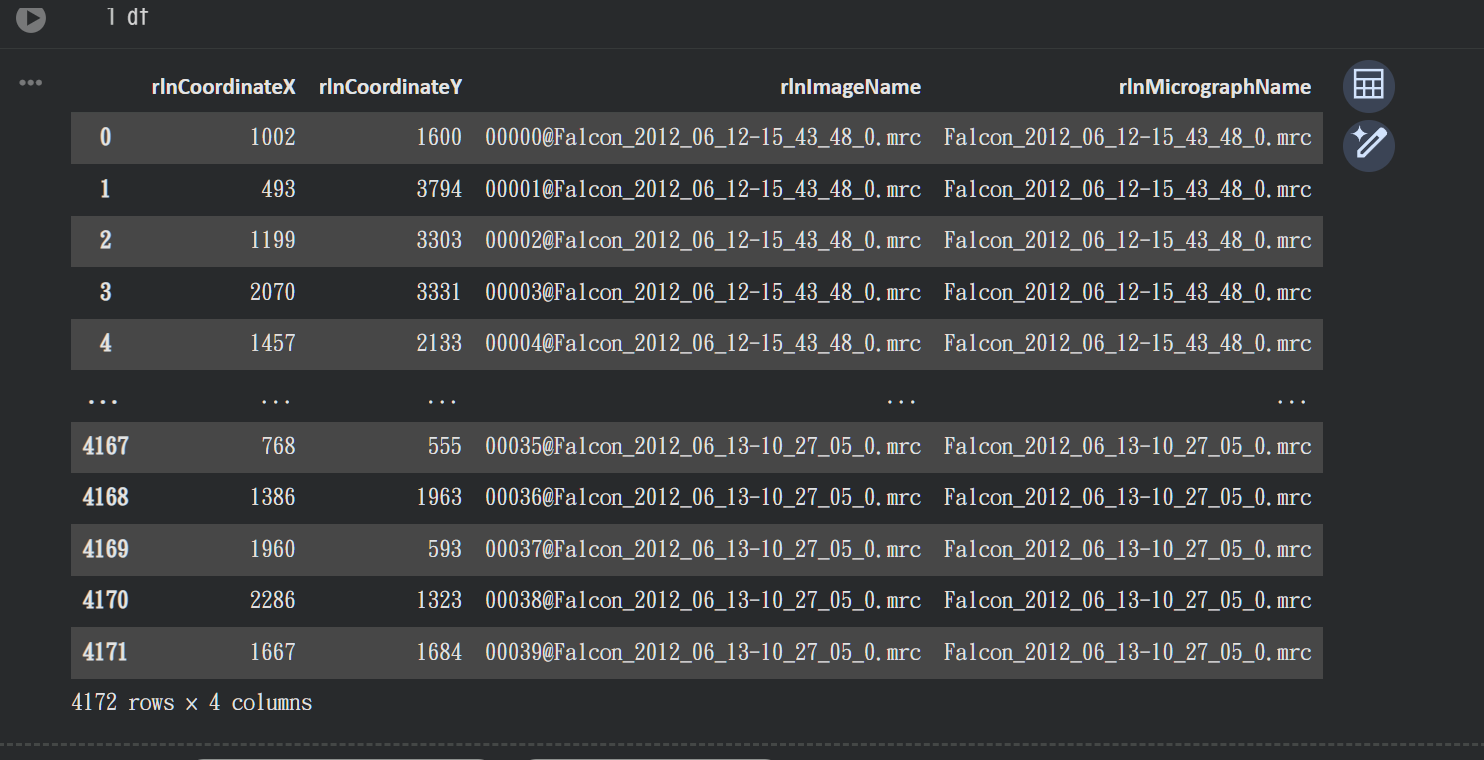